In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn nltk textblob wordcloud google-play-scraper streamlit

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 33.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   --------------------------------------- 625.0/625.0 kB 25.9 MB/s eta 0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [regex]
   ------ --------------------------------- 1/6 [regex]
   ------------- -------------------------- 2/6 [google-play-scraper]
   -------------------- ------------------- 3/6 [nltk]
   -------------------- ------------------- 3/6 [nltk]
   -------------------- ------------------- 3/6 [nltk]
   -------------------- ------------------- 3/6 [nltk]
   -------------------- ------------------- 3/6 [nltk]
   -------------------- ------------------- 3/6 [nltk]
  


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from google_play_scraper import reviews
import pandas as pd

In [3]:
result, continuation_token = reviews(
    'com.instagram.android',
    lang='en',
    country='us',
    count=1000
)

In [4]:
data = pd.DataFrame(result)

In [5]:
data.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,6a65d537-af49-43b0-a066-b2d5f5050fb4,lahcen “Rays” rami,https://play-lh.googleusercontent.com/a-/ALV-U...,amazing app,5,0,370.1.0.43.96,2026-05-25 17:37:54,None,None,370.1.0.43.96
1,3e14aafb-bd07-4ba8-83e6-ea31e4f1830b,Anpurana Devi,https://play-lh.googleusercontent.com/a/ACg8oc...,nice,5,0,430.0.0.53.80,2026-05-25 17:37:50,None,None,430.0.0.53.80
2,50d85893-c0dc-4ac8-86ce-b68f2b94c970,Baddam Harika,https://play-lh.googleusercontent.com/a-/ALV-U...,waste of using this instagram it's getting sus...,1,0,430.0.0.53.80,2026-05-25 17:36:50,None,None,430.0.0.53.80
3,7e25be3c-ccb8-4b7b-86a8-71a5f0743c82,Preety Chouhan,https://play-lh.googleusercontent.com/a/ACg8oc...,reels came on dependence of mood,5,0,NaN,2026-05-25 17:36:19,None,None,NaN
4,de3364e8-8cd5-42e7-ad42-6474fd56be72,سعید فرخ نژاد,https://play-lh.googleusercontent.com/a-/ALV-U...,اینستاگرام هوای ما ایرانیا رو داشته باش🥲,5,0,NaN,2026-05-25 17:35:58,None,None,NaN


In [6]:
data.to_csv("../dataset/instagram_reviews.csv", index=False)

In [7]:
data.shape

(1000, 11)

In [8]:
data.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='str')

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              1000 non-null   str           
 1   userName              1000 non-null   str           
 2   userImage             1000 non-null   str           
 3   content               1000 non-null   str           
 4   score                 1000 non-null   int64         
 5   thumbsUpCount         1000 non-null   int64         
 6   reviewCreatedVersion  663 non-null    str           
 7   at                    1000 non-null   datetime64[us]
 8   replyContent          0 non-null      object        
 9   repliedAt             0 non-null      object        
 10  appVersion            663 non-null    str           
dtypes: datetime64[us](1), int64(2), object(2), str(6)
memory usage: 313.0+ KB


In [10]:
data = data[["content", "score"]]

In [11]:
data.head()

,content,score
0,amazing app,5
1,nice,5
2,waste of using this instagram it's getting sus...,1
3,reels came on dependence of mood,5
4,اینستاگرام هوای ما ایرانیا رو داشته باش🥲,5


In [12]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [16]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kathir\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kathir\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kathir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    words = word_tokenize(text)

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [20]:
data["clean_review"] = data["content"].astype(str).apply(clean_text)

In [21]:
data.head()

,content,score,clean_review
0,amazing app,5,amazing app
1,nice,5,nice
2,waste of using this instagram it's getting sus...,1,waste using instagram getting suspending multi...
3,reels came on dependence of mood,5,reels came dependence mood
4,اینستاگرام هوای ما ایرانیا رو داشته باش🥲,5,


In [22]:
from textblob import TextBlob

In [23]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

In [24]:
data["sentiment"] = data["clean_review"].apply(get_sentiment)

In [25]:
data.head()

,content,score,clean_review,sentiment
0,amazing app,5,amazing app,Positive
1,nice,5,nice,Positive
2,waste of using this instagram it's getting sus...,1,waste using instagram getting suspending multi...,Negative
3,reels came on dependence of mood,5,reels came dependence mood,Neutral
4,اینستاگرام هوای ما ایرانیا رو داشته باش🥲,5,,Neutral


In [26]:
data["sentiment"].value_counts()

sentiment
Positive    563
Neutral     296
Negative    141
Name: count, dtype: int64

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

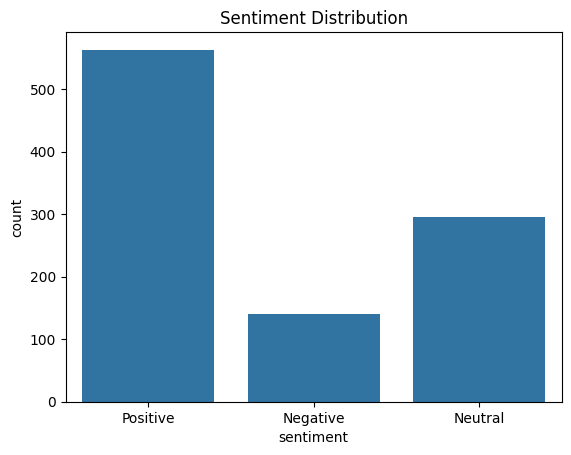

In [28]:
sns.countplot(x="sentiment", data=data)

plt.title("Sentiment Distribution")

plt.savefig("../images/sentiment_distribution.png")

plt.show()

In [29]:
from wordcloud import WordCloud


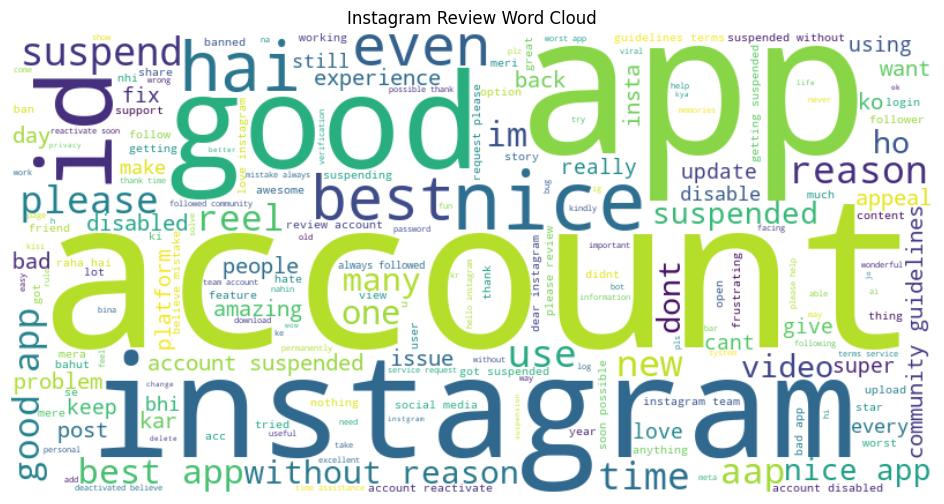

In [30]:
text = " ".join(data["clean_review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Instagram Review Word Cloud")

plt.savefig("../images/wordcloud.png")

plt.show()